In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from neurocaps.extraction import TimeseriesExtractor
from neurocaps.utils import simulate_bids_dataset

/home/linjh/anaconda3/envs/neurocaps/lib/python3.14/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
OUTPUT_ROOT = Path("./outputs/PDNeuroCAPs")
EXTRACTION_DIR = OUTPUT_ROOT / "01_extraction"
CLUSTER_DIR = OUTPUT_ROOT / "02_clustering"
METRICS_DIR = OUTPUT_ROOT / "03_metrics"
LABELS_DIR = OUTPUT_ROOT / "04_framewise_labels"
TEMPLATES_DIR = OUTPUT_ROOT / "05_cap_templates"

for _dir in [OUTPUT_ROOT, EXTRACTION_DIR, CLUSTER_DIR, METRICS_DIR, LABELS_DIR, TEMPLATES_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

# Import function implementations from scripts module
from scripts.notebook_utils import (
    get_roi_labels,
    save_subject_timeseries_csv,
    save_cluster_scores,
    save_predicted_labels,
    save_cap_templates,
)

In [3]:
# Set seed
np.random.seed(0)

# Generate a BIDS directory with fMRIPrep derivatives
# bids_root = simulate_bids_dataset(n_subs=3, n_runs=1, n_volumes=100, task_name="rest")
# print(f"BIDS dataset created at: {bids_root}")
bids_root = "./MyDataSet_Reorganized"

# Using custom A283 parcellation
from atlas283_custom_parcellation import ATLAS283_CUSTOM
import copy
parcel_approach = copy.deepcopy(ATLAS283_CUSTOM)

# List of fMRIPrep-derived confounds for nuisance regression
acompcor_names = [f"a_comp_cor_0{i}" for i in range(5)]
confound_names = ["cosine*", "trans*", "rot*", *acompcor_names]

# Initialize extractor with signal cleaning parameters
extractor = TimeseriesExtractor(
    space="MNI152NLin6Asym",
    parcel_approach=parcel_approach,
    confound_names=confound_names,
    standardize=True,
    # Run discarded if more than 30% of volumes exceed FD threshold
    fd_threshold={"threshold": 0.90, "outlier_percentage": 0.30},
)

# Paths for cache files
subject_ts_cache = EXTRACTION_DIR / "subject_timeseries.pkl"
qc_cache = EXTRACTION_DIR / "qc_report.csv"

# Clear cache if directory structure has changed
TimeseriesExtractor._call_layout.cache_clear()

# Check local cache before running extraction
if subject_ts_cache.exists():
    print(f"[INFO] Found cached timeseries: {subject_ts_cache}")
    extractor.subject_timeseries = str(subject_ts_cache)
    print("[INFO] Loaded subject_timeseries from cache. Skip get_bold().")

    if qc_cache.exists():
        qc_df = pd.read_csv(qc_cache)
        print(f"[INFO] Loaded cached QC report: {qc_cache}")
    else:
        qc_df = None
        print(f"[WARN] QC cache not found: {qc_cache}")
else:
    print("[INFO] Cache not found. Running get_bold().")
    extractor.get_bold(bids_dir=bids_root, task="rest", tr=0.735, n_cores=3, verbose=True)

    extractor.timeseries_to_pickle(
        output_dir=str(EXTRACTION_DIR),
        filename="subject_timeseries.pkl",
    )

    qc_df = extractor.report_qc(
        output_dir=str(EXTRACTION_DIR),
        filename="qc_report.csv",
        return_df=True,
    )
    print(f"[INFO] Saved cache file: {subject_ts_cache}")

    # Save all extracted timeseries into per-subject/run files (csv + npz)
    first_subj = next(iter(extractor.subject_timeseries))
    first_run = next(iter(extractor.subject_timeseries[first_subj]))
    n_rois = extractor.subject_timeseries[first_subj][first_run].shape[1]
    roi_labels = get_roi_labels(parcel_approach, n_rois)
    ts_summary_df = save_subject_timeseries_csv(
        extractor.subject_timeseries,
        output_dir=EXTRACTION_DIR / "timeseries_files",
        roi_labels=roi_labels,
        save_wide_csv=True,
        save_long_csv=False,
        save_npz=True,
        write_index_json=True,
    )

if qc_df is not None:
    print("QC preview:")
    print(qc_df.head())
else:
    print("QC preview: no cached qc_report.csv available")

2026-05-18 20:52:06,292 neurocaps.extraction._internals.confounds [INFO] Confound regressors to be used if available: cosine*, trans*, rot*, a_comp_cor_00, a_comp_cor_01, a_comp_cor_02, a_comp_cor_03, a_comp_cor_04.
[INFO] Found cached timeseries: outputs/PDNeuroCAPs/01_extraction/subject_timeseries.pkl
[INFO] Loaded subject_timeseries from cache. Skip get_bold().
[INFO] Loaded cached QC report: outputs/PDNeuroCAPs/01_extraction/qc_report.csv
QC preview:
  Subject_ID    Run   Mean_FD    Std_FD  Frames_Scrubbed  Frames_Interpolated  \
0       0001  run-0  0.206504  0.112888                1                    0   
1       0003  run-0  0.181415  0.117654                0                    0   
2       0004  run-0  0.152052  0.080179                0                    0   
3       0005  run-0  0.211050  0.110780                0                    0   
4       0006  run-0  0.137120  0.075944                0                    0   

   Mean_High_Motion_Length  Std_High_Motion_Length  N_

In [4]:
from neurocaps.analysis import CAP
from neurocaps.utils import PlotDefaults
import pickle

groups = None
cap_cache = CLUSTER_DIR / "cap_analysis.pkl"

plot_kwargs = {**PlotDefaults.get_caps(), "figsize": (4, 3), "step": 2}

if cap_cache.exists():
    print(f"[INFO] Found CAP cache: {cap_cache}")
    with open(cap_cache, "rb") as f:
        cap_analysis = pickle.load(f)
    cap_analysis.parcel_approach = extractor.parcel_approach
    print("[INFO] Loaded cap_analysis from cache. Skip get_caps().")
else:
    # Initialize CAP class with explicit groups
    cap_analysis = CAP(parcel_approach=extractor.parcel_approach, groups=groups)

    # Find optimal CAPs (2-20) using elbow method
    cap_analysis.get_caps(
        subject_timeseries=extractor.subject_timeseries,
        n_clusters=range(2, 21),
        standardize=True,
        cluster_selection_method="elbow",
        random_state=0,
        max_iter=500,
        n_init=1000,
        output_dir=str(CLUSTER_DIR),
        show_figs=True,
        progress_bar=True,
        **plot_kwargs,
    )

    with open(cap_cache, "wb") as f:
        pickle.dump(cap_analysis, f)
    print(f"[INFO] Saved CAP cache: {cap_cache}")

# Save cluster selection scores (e.g., elbow for each k)
cluster_score_df = save_cluster_scores(cap_analysis.cluster_scores, CLUSTER_DIR)
if cluster_score_df is not None:
    print("Cluster score preview:")
    print(cluster_score_df.head())
else:
    print("No cluster selection scores were generated.")

[INFO] Found CAP cache: outputs/PDNeuroCAPs/02_clustering/cap_analysis.pkl
[INFO] Loaded cap_analysis from cache. Skip get_caps().
Cluster score preview:
          Group Cluster_Selection_Method  k       Score
0  All Subjects                    elbow  2  90009248.0
1  All Subjects                    elbow  3  87340144.0
2  All Subjects                    elbow  4  85510384.0
3  All Subjects                    elbow  5  84133480.0
4  All Subjects                    elbow  6  83163904.0


In [5]:
# ========== Bootstrapping Clustering Stability ==========
import importlib
import scripts.bootstrap_clustering_stability_utils
importlib.reload(scripts.bootstrap_clustering_stability_utils)

from scripts.bootstrap_clustering_stability_utils import run_bootstrap_clustering_stability

# Run Bootstrap clustering stability assessment (resample and match models with completed get_caps)
run_bootstrap_clustering_stability(
    cap_analysis=cap_analysis,
    n_boot=1000,
    output_dir=str(CLUSTER_DIR),
    n_init_boot=10,
    use_cached_data=True,
)

[INFO] Group 'All Subjects': Preparing Bootstrap clustering stability assessment...
[INFO] use_cached_data=True and local files detected.
[INFO] ---> Skipping Bootstrap computation, reading from cache and generating plots...

=== Bootstrap Clustering Spatial Stability (Pearson Centroid Correlation, 95% CI) ===
 CAP_Index  Mean_Correlation  Median_Correlation  Std_Correlation  95%_CI_Low  95%_CI_High
         1          0.994963            0.998788         0.041871    0.994015     0.999732
         2          0.994742            0.998557         0.042013    0.992531     0.999690
         3          0.998292            0.999321         0.009504    0.996241     0.999830
         4          0.999780            0.999877         0.000818    0.999538     0.999960
         5          0.999770            0.999875         0.000855    0.999421     0.999956
         6          0.997528            0.999502         0.020604    0.996730     0.999903
         7          0.999299            0.999582   

(   CAP_Index  Mean_Correlation  Median_Correlation  Std_Correlation  \
 0          1          0.994963            0.998788         0.041871   
 1          2          0.994742            0.998557         0.042013   
 2          3          0.998292            0.999321         0.009504   
 3          4          0.999780            0.999877         0.000818   
 4          5          0.999770            0.999875         0.000855   
 5          6          0.997528            0.999502         0.020604   
 6          7          0.999299            0.999582         0.001584   
 
    95%_CI_Low  95%_CI_High  
 0    0.994015     0.999732  
 1    0.992531     0.999690  
 2    0.996241     0.999830  
 3    0.999538     0.999960  
 4    0.999421     0.999956  
 5    0.996730     0.999903  
 6    0.997772     0.999899  ,
 array([[0.99677929, 0.9977764 , 0.99796412, ..., 0.99995477, 0.99801544,
         0.99909589],
        [0.99889251, 0.99949814, 0.99951101, ..., 0.99990192, 0.99977567,
         0.

In [6]:
# ========== CAP Reordering (calling scripts module) ==========
# Original order: 1 2 3 4 5 6 7
# Target order: 6 7 3 2 5 4 1

from scripts.cap_reorder_utils import reorder_caps_with_state_check

new_cap_order = [6, 7, 3, 2, 5, 4, 1]
reorder_caps_with_state_check(cap_analysis, cap_cache, new_cap_order, force=False)

[INFO] CAPs already reordered, skipping reorder operation
Applied reorder mapping: {'new_order': [6, 7, 3, 2, 5, 4, 1], 'timestamp': '2026-05-06T17:41:51.265034'}

To reorder again, re-run this cell with force=True


False

In [7]:
# Calculate and save CAP-related metrics
metric_dict = cap_analysis.calculate_metrics(
    subject_timeseries=extractor.subject_timeseries,
    metrics=[
        "temporal_fraction",
        "persistence",
        "counts",
        "transition_frequency",
        "transition_probability",
    ],
    tr=0.735,
    output_dir=str(METRICS_DIR),
    prefix_filename="all_subjects",
    return_df=True,
)

print("Metric keys:", list(metric_dict.keys()))
print("\nTemporal fraction preview:")
print(metric_dict["temporal_fraction"].head())
print("\nPersistence preview:")
print(metric_dict["persistence"].head())
print("\nCounts preview:")
print(metric_dict["counts"].head())
print("\nTransition frequency preview:")
print(metric_dict["transition_frequency"].head())
if "transition_probability" in metric_dict:
    print("\nTransition probability preview (All Subjects):")
    print(metric_dict["transition_probability"]["All Subjects"].head())

print(metric_dict["counts"]["CAP-2"])

# Save frame-wise CAP labels for each subject/run
predicted_labels = cap_analysis.return_cap_labels(
    subject_timeseries=extractor.subject_timeseries,
    runs=None,
    continuous_runs=False,
    shift_labels=True,
)
labels_df = save_predicted_labels(predicted_labels, LABELS_DIR)
print("\nFrame-wise CAP label preview:")
print(labels_df.head())

# Save CAP template values (each CAP centroid as numeric table)
cap_template_tables = save_cap_templates(
    caps=cap_analysis.caps,
    parcel_approach=cap_analysis.parcel_approach,
    output_dir=TEMPLATES_DIR,
    save_long_csv=True,
)
print("\nCAP template groups:", list(cap_template_tables.keys()))
for group_name, cap_df in cap_template_tables.items():
    print(f"\nTemplate preview for group: {group_name}")
    print(cap_df.iloc[:, : min(8, cap_df.shape[1])].head())

# Export radar and CAP-correlation data as CSV into 05_cap_templates
_safe_group_name = lambda x: "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(x))

# 1) Radar data (cosine similarity)
cap_analysis.caps2radar(show_figs=False)
for group_name, radar_dict in cap_analysis.cosine_similarity.items():
    regions = radar_dict["Regions"]
    cap_rows = []

    for cap_name, cap_vals in radar_dict.items():
        if cap_name == "Regions":
            continue
        high = np.asarray(cap_vals["High Amplitude"]).ravel()
        low = np.asarray(cap_vals["Low Amplitude"]).ravel()
        # net = high - low

        cap_df = pd.DataFrame(
            {
                "Group": group_name,
                "CAP": cap_name,
                "Region": regions,
                "High_Amplitude": high,
                "Low_Amplitude": low,
                # "Net": net,
            }
        )
        cap_rows.append(cap_df)

    if cap_rows:
        radar_group_df = pd.concat(cap_rows, ignore_index=True)
        radar_group_df.to_csv(
            TEMPLATES_DIR / f"radar_cosine_similarity_{_safe_group_name(group_name)}.csv",
            index=False,
        )

# 2) CAP correlation matrices
corr_dict = cap_analysis.caps2corr(
    method="pearson",
    save_plots=False,
    save_df=False,
    show_figs=False,
    return_df=True,
)

for group_name, corr_df in corr_dict.items():
    safe_group = _safe_group_name(group_name)
    corr_df.to_csv(
        TEMPLATES_DIR / f"cap_correlation_{safe_group}_pearson_annotated.csv",
        index=True,
    )

    corr_numeric = pd.DataFrame(cap_analysis.caps[group_name]).corr(method="pearson")
    corr_numeric.to_csv(
        TEMPLATES_DIR / f"cap_correlation_{safe_group}_pearson_numeric.csv",
        index=True,
    )

print(f"\n[INFO] Radar and CAP correlation CSVs saved to: {TEMPLATES_DIR}")

from scripts.merge_metrics_long_table_utils import merge_files

merge_files(METRICS_DIR)

Metric keys: ['temporal_fraction', 'persistence', 'counts', 'transition_frequency', 'transition_probability']

Temporal fraction preview:
  Subject_ID         Group    Run     CAP-1     CAP-2     CAP-3     CAP-4  \
0       0001  All Subjects  run-0  0.114823  0.125261  0.114823  0.179541   
1       0003  All Subjects  run-0  0.097917  0.156250  0.118750  0.197917   
2       0004  All Subjects  run-0  0.147917  0.114583  0.087500  0.208333   
3       0005  All Subjects  run-0  0.195833  0.093750  0.087500  0.120833   
4       0006  All Subjects  run-0  0.127083  0.150000  0.160417  0.145833   

      CAP-5     CAP-6     CAP-7  
0  0.169102  0.144050  0.152401  
1  0.210417  0.100000  0.118750  
2  0.216667  0.116667  0.108333  
3  0.152083  0.154167  0.195833  
4  0.158333  0.122917  0.135417  

Persistence preview:
  Subject_ID         Group    Run     CAP-1     CAP-2     CAP-3     CAP-4  \
0       0001  All Subjects  run-0  1.684375  2.004545  2.127632  3.160500   
1       0003  All S

[{'Subject_ID': '0001',
  'Group': 'PD',
  'Run': 'run-0',
  'Metric': 'counts',
  'Feature': 'CAP-1',
  'Value': '24'},
 {'Subject_ID': '0001',
  'Group': 'PD',
  'Run': 'run-0',
  'Metric': 'counts',
  'Feature': 'CAP-2',
  'Value': '22'},
 {'Subject_ID': '0001',
  'Group': 'PD',
  'Run': 'run-0',
  'Metric': 'counts',
  'Feature': 'CAP-3',
  'Value': '19'},
 {'Subject_ID': '0001',
  'Group': 'PD',
  'Run': 'run-0',
  'Metric': 'counts',
  'Feature': 'CAP-4',
  'Value': '20'},
 {'Subject_ID': '0001',
  'Group': 'PD',
  'Run': 'run-0',
  'Metric': 'counts',
  'Feature': 'CAP-5',
  'Value': '23'},
 {'Subject_ID': '0001',
  'Group': 'PD',
  'Run': 'run-0',
  'Metric': 'counts',
  'Feature': 'CAP-6',
  'Value': '18'},
 {'Subject_ID': '0001',
  'Group': 'PD',
  'Run': 'run-0',
  'Metric': 'counts',
  'Feature': 'CAP-7',
  'Value': '20'},
 {'Subject_ID': '0003',
  'Group': 'PD',
  'Run': 'run-0',
  'Metric': 'counts',
  'Feature': 'CAP-1',
  'Value': '19'},
 {'Subject_ID': '0003',
  'Group

2026-05-18 20:52:08,580 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmpempr607z.nii.gz]


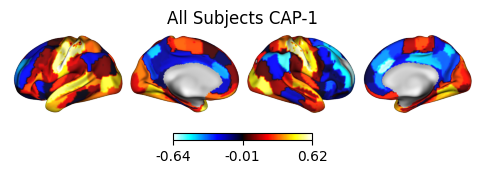

2026-05-18 20:52:09,626 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmp3qs2el_6.nii.gz]


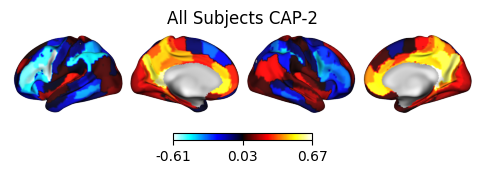

2026-05-18 20:52:10,380 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmpkja3hoeg.nii.gz]


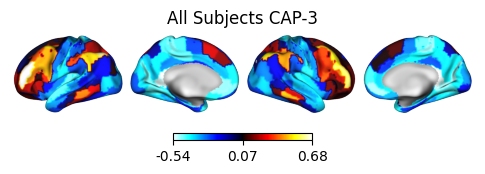

2026-05-18 20:52:11,083 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmpcg8n67n7.nii.gz]


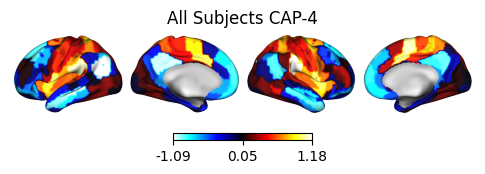

2026-05-18 20:52:11,823 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmpilimpv6q.nii.gz]


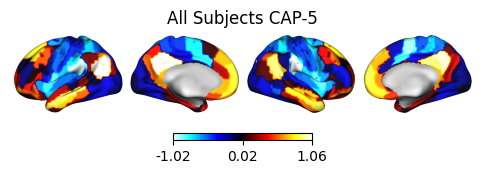

2026-05-18 20:52:12,493 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmpuuhus1vt.nii.gz]


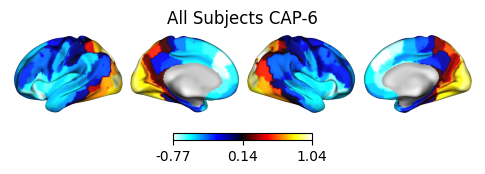

2026-05-18 20:52:13,202 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmpo8bfsp3v.nii.gz]


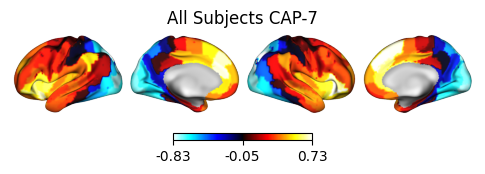

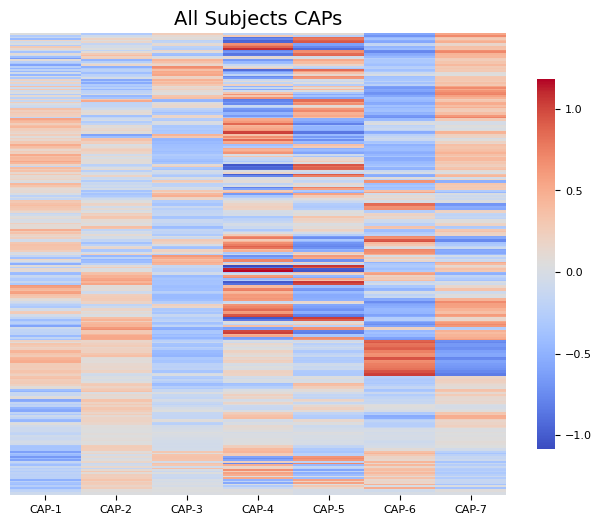

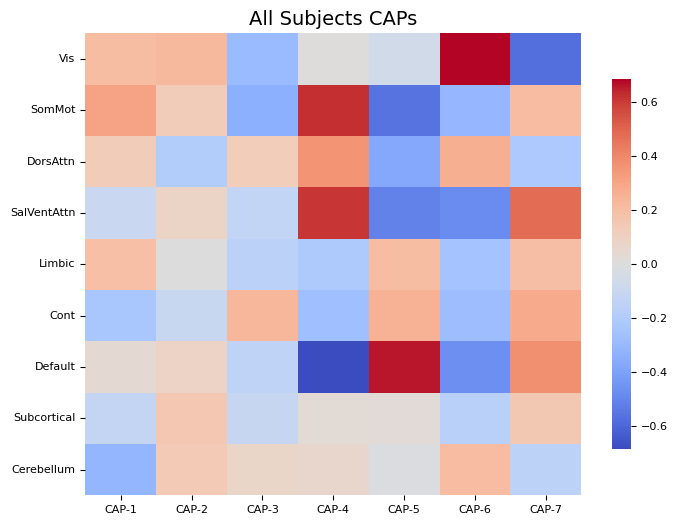

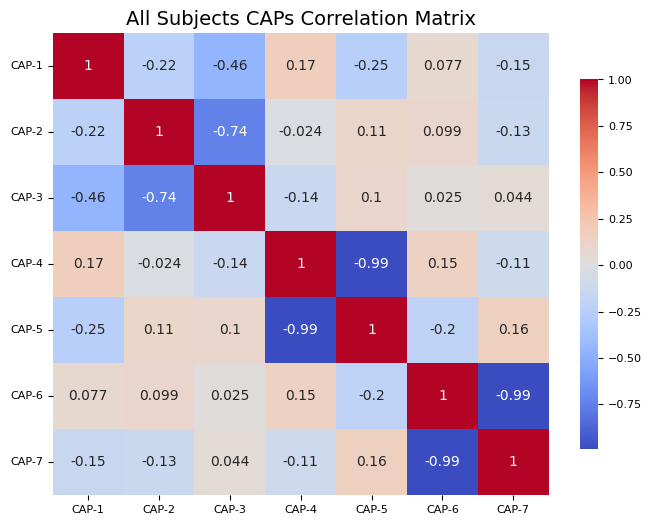

In [8]:
surface_kwargs = {**PlotDefaults.caps2surf(), "layout": "row", "size": (500, 100)}

radar_kwargs = {**PlotDefaults.caps2radar(), "height": 400, "width": 600}
radar_kwargs["radialaxis"] = {"range": [0, 0.8], "tickvals": [0.1, "", "", 0.8]}
radar_kwargs["legend"] = {"yanchor": "top", "y": 0.8, "x": 1.15}

plot_kwargs = {**PlotDefaults.caps2plot()}

corr_kwargs = {**PlotDefaults.caps2corr()}

cap_analysis.caps2surf(**surface_kwargs)
cap_analysis.caps2radar(**radar_kwargs)
cap_analysis.caps2plot(**plot_kwargs, visual_scope="nodes")
cap_analysis.caps2plot(**plot_kwargs)
# cap_analysis.caps2plot(**plot_kwargs, plot_options="outer_product")
cap_analysis.caps2corr(**corr_kwargs)

In [9]:
STATS_DATASETS_DIR = OUTPUT_ROOT / "06_statistics_datasets"

from scripts.prepare_statistical_datasets_utils import prepare_statistical_datasets
stats_datasets = prepare_statistical_datasets(
    clinical_csv_path = "./data/merged_clinical_metrics.csv",
    metrics_csv_path = str(METRICS_DIR / "all_metrics_long.csv"),
    qc_csv_path = str(EXTRACTION_DIR / "qc_report.csv"),
    output_dir = str(STATS_DATASETS_DIR)
)

[INFO] Reading raw data...
[INFO] Processing and pivoting metrics data...
[INFO] Merging metrics, QC, and clinical data...
 -> Merged base table generated (total rows: 713)
[INFO] Generating cross-sectional table (HC vs PD-OFF)...
 -> Cross-sectional table generated (HC: 141, PD: 337)
[INFO] Generating longitudinal paired wide table (PD OFF vs ON)...
 -> Longitudinal paired table generated (subjects with both pre/post: 235)


In [10]:
import importlib
import scripts.statistics_ancova_lmm_utils
import scripts.statistics_ancova_lmm_plot_utils
importlib.reload(scripts.statistics_ancova_lmm_utils)
importlib.reload(scripts.statistics_ancova_lmm_plot_utils)
from scripts.statistics_ancova_lmm_utils import run_statistical_pipeline
from scripts.statistics_ancova_lmm_plot_utils import generate_all_visualizations
STATS_ANCOVA_LMM_DIR = OUTPUT_ROOT / "07_statistics_ANCOVA_LMM"

run_statistical_pipeline(
    cross_csv = str(STATS_DATASETS_DIR / "02_cross_sectional_base.csv"),
    long_wide_csv = str(STATS_DATASETS_DIR / "03_longitudinal_paired_wide.csv"),
    output_dir = str(STATS_ANCOVA_LMM_DIR)
)

generate_all_visualizations(
    data_dir = STATS_DATASETS_DIR,
    stats_dir = STATS_ANCOVA_LMM_DIR,
    output_dir = STATS_ANCOVA_LMM_DIR
)

[INFO] Running ANCOVA (Cross-sectional)...


/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/statistics_ancova_lmm_plot_utils.py:144: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax.set_ylabel(f"$\Delta$ {feat} (OFF - ON)")


[INFO] Running LMM (Longitudinal)...
[INFO] Results merged and saved to: outputs/PDNeuroCAPs/07_statistics_ANCOVA_LMM/all_cross_longitudinal_merged.csv
[SUCCESS] Statistical analysis complete! Results saved to: outputs/PDNeuroCAPs/07_statistics_ANCOVA_LMM
[INFO] Generating ANCOVA cross-sectional raincloud plots...
[INFO] Generating LMM longitudinal delta raincloud plots...
[INFO] Generating LMM residual diagnostic plots...
[SUCCESS] All visualizations complete! Figures saved to: outputs/PDNeuroCAPs/07_statistics_ANCOVA_LMM


In [11]:
import importlib
import scripts.statistics_correlation_utils
importlib.reload(scripts.statistics_correlation_utils)
from scripts.statistics_correlation_utils import run_correlation_pipeline

STATS_CORRELATION_DIR = OUTPUT_ROOT / "08_statistics_correlation"

run_correlation_pipeline(
    data_dir=STATS_DATASETS_DIR,
    output_dir=STATS_CORRELATION_DIR
)

[INFO] Starting correlation analysis (Spearman Partial Correlation)...
 -> Cross-sectional analysis complete (tested 71 features)
 -> Longitudinal analysis group [All_PD] complete (tested 71 delta features)
 -> Longitudinal analysis group [Responder] complete (tested 71 delta features)
 -> Longitudinal analysis group [Non-responder] complete (tested 71 delta features)

[SUCCESS] Correlation analysis complete!
Total tests performed: 284
Significant associations (p_FDR < 0.05): 2
Output summary file: outputs/PDNeuroCAPs/08_statistics_correlation/correlation_results_summary.csv


In [12]:
import importlib
import scripts.response_lmm_interaction_utils
importlib.reload(scripts.response_lmm_interaction_utils)

from scripts.response_lmm_interaction_utils import run_response_lmm_interaction_pipeline

LMM_INTERACTION_DIR = OUTPUT_ROOT / "09_response_lmm_interaction"
run_response_lmm_interaction_pipeline(
    data_dir = STATS_DATASETS_DIR,
    output_dir = LMM_INTERACTION_DIR
)

[INFO] Successfully read longitudinal wide table, total pairs: 235
[INFO] Clinical response defined (threshold: 30.0%): Responder=142, Non-responder=93
[INFO] Running interaction effect analysis on 71 imaging features...


/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_lmm_interaction_utils.py:291: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_long['Delta_UPDRS'] = delta_u
/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_lmm_interaction_utils.py:292: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_long['PctChange_UPDRS'] = pct_u
/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_lmm_interaction_utils.py:293: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `


[SUCCESS] Interaction effect (LMM) analysis complete!
Number of successfully fitted models: 71
Significant interaction features (p_FDR < 0.05): 1
Output summary directory: outputs/PDNeuroCAPs/09_response_lmm_interaction


In [13]:
import importlib
import scripts.response_llm_stratified_utils
importlib.reload(scripts.response_llm_stratified_utils)

from scripts.response_llm_stratified_utils import run_response_stratified_pipeline

STRATIFIED_LMM_DIR = OUTPUT_ROOT / "10_response_lmm_stratified"
run_response_stratified_pipeline(
    data_dir = STATS_DATASETS_DIR,
    output_dir = STRATIFIED_LMM_DIR
)

[INFO] Starting three-way interaction and gender stratified analysis...
[DEBUG] Total candidate numeric features: 71

--- Testing feature: counts_CAP-1 ---


/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_llm_stratified_utils.py:346: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_long['Delta_UPDRS'] = delta_u
/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_llm_stratified_utils.py:347: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_long['PctChange_UPDRS'] = pct_u
/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_llm_stratified_utils.py:349: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fra


--- Testing feature: counts_CAP-2 ---

--- Testing feature: counts_CAP-3 ---
[SUCCESS] Step 1 overall model saved -> 01_overall_3way_lmm_summary.csv
[SUCCESS] Step 2 gender stratified model saved -> 02_stratified_subcohort_lmm_summary.csv


In [14]:
import importlib
import scripts.svm_response_prediction_utils
importlib.reload(scripts.svm_response_prediction_utils)

from scripts.svm_response_prediction_utils import run_svm_response_prediction_pipeline

SVM_DIR = OUTPUT_ROOT / "11_svm_response_prediction"

run_svm_response_prediction_pipeline(
    data_dir = STATS_DATASETS_DIR,
    output_dir = SVM_DIR,
    feature_specs = [
        "counts_CAP-2",
        "transition_probability_2.5",
    ],
    n_splits=5,
    n_repeats=5,
    response_threshold_pct=30.0,
    permutation_test=True,
)

[INFO] Building 4 models (including base).
[INFO] [1/4] Training base | feature_idxs=none


/home/linjh/anaconda3/envs/neurocaps/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/linjh/anaconda3/envs/neurocaps/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/linjh/anaconda3/envs/neurocaps/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain fr

[INFO] [2/4] Training base_1 | feature_idxs=1
[INFO] [3/4] Training base_2 | feature_idxs=2
[INFO] [4/4] Training base_1_2 | feature_idxs=1,2
[INFO] Total comparison pairs (subset->superset): 5
[INFO] [Pair 1/5] Comparing base_1 vs base
[INFO] [Pair 1/5] Bootstrap 5 metrics (n_boot=1000)
[INFO] [Pair 1/5] Bootstrap NRI (n_boot=1000)
[INFO] [Pair 2/5] Comparing base_2 vs base
[INFO] [Pair 2/5] Bootstrap 5 metrics (n_boot=1000)
[INFO] [Pair 2/5] Bootstrap NRI (n_boot=1000)
[INFO] [Pair 3/5] Comparing base_1_2 vs base
[INFO] [Pair 3/5] Bootstrap 5 metrics (n_boot=1000)
[INFO] [Pair 3/5] Bootstrap NRI (n_boot=1000)
[INFO] [Pair 4/5] Comparing base_1_2 vs base_1
[INFO] [Pair 4/5] Bootstrap 5 metrics (n_boot=1000)
[INFO] [Pair 4/5] Bootstrap NRI (n_boot=1000)
[INFO] [Pair 5/5] Comparing base_1_2 vs base_2
[INFO] [Pair 5/5] Bootstrap 5 metrics (n_boot=1000)
[INFO] [Pair 5/5] Bootstrap NRI (n_boot=1000)

[INFO] Running 1000 Permutation Tests for base_1_2... (this may take a while)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   20.9s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 402 tasks      | elapsed:  6.3min
[Parallel(n_jobs=-1)]: Done 752 tasks      | elapsed: 11.8min


[INFO] Permutation Test complete! True AUC: 0.5994, p-value: 0.0170
[INFO] SVM response prediction complete. Output dir: outputs/PDNeuroCAPs/11_svm_response_prediction
[INFO] Evaluator: _evaluate_svm_nested_cv; n_splits=5; n_repeats=5
[INFO] Base feature columns: ['UPDRS-III(OFF)', 'Age', 'Gender', 'Years of Education']
[INFO] Input feature specs: ['counts_CAP-2', 'transition_probability_2.5']
[INFO] Models trained: 4


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed: 15.5min finished
